       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  

Dataset Shape : (27481, 4)

Remaining Data : (16363, 4)

Cleaned Text Sample:

                                                text  \
1      Sooo SAD I will miss you here in San Diego!!!   
2                          my boss is bullying me...   
3                     what interview!

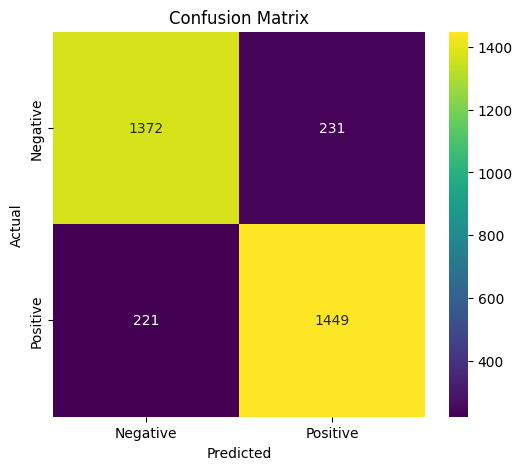


Enter a tweet/document (type 'exit' to stop):  Not happy



Cleaned Text : sad
Predicted Sentiment : Negative



Enter a tweet/document (type 'exit' to stop):  Dont love it



Cleaned Text : hate it
Predicted Sentiment : Negative



Enter a tweet/document (type 'exit' to stop):  Not ugly


...


Cleaned Text : nice
Predicted Sentiment : Positive



Enter a tweet/document (type 'exit' to stop):  not nice



Cleaned Text : not nice
Predicted Sentiment : Positive



Enter a tweet/document (type 'exit' to stop):  exit



Program Ended.


In [5]:
# ----------------------------------------
# Import Libraries
# ----------------------------------------

import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ----------------------------------------
# Load Dataset
# ----------------------------------------

df = pd.read_csv("Tweets.csv")

print(df.head())

print("\nDataset Shape :", df.shape)

# ----------------------------------------
# Keep Only Positive and Negative Tweets
# ----------------------------------------

df = df[
    df["sentiment"].isin([
        "positive",
        "negative"
    ])
]

# Remove missing values
df = df.dropna()

print("\nRemaining Data :", df.shape)

# ----------------------------------------
# Negation Handling Function
# ----------------------------------------

def handle_negation(text):

    text = text.lower()

    replacements = {

        "don't like": "hate",
        "dont like": "hate",

        "don't love": "hate",
        "dont love": "hate",

        "not ugly": "beautiful",
        "not bad": "good",
        "not sad": "happy",
        "not hate": "love",
        "not nice":"bad",

        "not beautiful": "ugly",
        "not good": "bad",
        "not happy": "sad",

        "very easy": "easy",
        "very hard": "hard"
    }

    for phrase, replacement in replacements.items():

        text = text.replace(
            phrase,
            replacement
        )

    return text

# ----------------------------------------
# Text Cleaning Function
# ----------------------------------------

def clean_text(text):

    text = str(text)

    # Handle negation first
    text = handle_negation(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol
    text = re.sub(r"#", "", text)

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing spaces
    text = text.strip()

    return text

# ----------------------------------------
# Apply Text Cleaning
# ----------------------------------------

df["clean_text"] = df["text"].apply(clean_text)

print("\nCleaned Text Sample:\n")

print(
    df[["text", "clean_text"]].head()
)

# ----------------------------------------
# TF-IDF Vectorization
# ----------------------------------------

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    stop_words='english',
    max_features=10000
)

X = vectorizer.fit_transform(
    df["clean_text"]
)

# Labels
y = df["sentiment"]

# ----------------------------------------
# Train Test Split
# ----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ----------------------------------------
# SVM Model
# ----------------------------------------

model = LinearSVC()

model.fit(X_train, y_train)

# ----------------------------------------
# Prediction
# ----------------------------------------

y_pred = model.predict(X_test)

# ----------------------------------------
# Accuracy
# ----------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "\nModel Accuracy :",
    round(accuracy * 100, 2),
    "%"
)

# ----------------------------------------
# Classification Report
# ----------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ----------------------------------------
# Confusion Matrix
# ----------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:\n")

print(cm)

# ----------------------------------------
# Confusion Matrix Heatmap
# ----------------------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# ----------------------------------------
# Real-Time User Prediction
# ----------------------------------------

while True:

    user_text = input(
        "\nEnter a tweet/document (type 'exit' to stop): "
    )

    # Exit condition
    if user_text.lower() == "exit":

        print("\nProgram Ended.")

        break

    # Clean user text
    cleaned = clean_text(user_text)

    # Convert into vector
    vector_input = vectorizer.transform(
        [cleaned]
    )

    # Predict sentiment
    prediction = model.predict(
        vector_input
    )

    print(
        "\nCleaned Text :",
        cleaned
    )

    print(
        "Predicted Sentiment :",
        prediction[0].capitalize()
    )

USE ONLY WHEN DATASET NOT THERE

In [ ]:
import re

def classify_document_lexicon(document):
    positive_words = {
        "good","great","excellent","amazing","happy","love","wonderful","best",
        "awesome","fantastic","nice","positive","enjoy","liked","brilliant"
    }
    negative_words = {
        "bad","terrible","awful","sad","hate","worst","poor","disappointing",
        "horrible","negative","boring","annoying","dislike","pathetic"
    }
    negation_words = {"not", "no", "never", "n't"}
    intensifiers = {"very": 1.5, "extremely": 2, "really": 1.3, "so": 1.2}

    words = re.findall(r'\b\w+\b', document.lower())

    score = 0
    negate = False
    intensity = 1

    for word in words:
        if word in negation_words:
            negate = True
            continue

        if word in intensifiers:
            intensity = intensifiers[word]
            continue

        if word in positive_words:
            val = 1 * intensity
            score += -val if negate else val
            negate = False
            intensity = 1

        elif word in negative_words:
            val = -1 * intensity
            score += -val if negate else val
            negate = False
            intensity = 1

        else:
            negate = False
            intensity = 1

    if score > 0:
        return "POSITIVE"
    elif score < 0:
        return "NEGATIVE"
    else:
        return "NEUTRAL"

In [ ]:

doc1 = "I love this product! It is an amazing and great tool."
doc2 = "This was a terrible experience. The service was bad and awful."
doc3 = "The weather is okay, but my coffee is very cold but bad"
doc4= "not bad"

print(classify_document_lexicon(doc1))
print(classify_document_lexicon(doc2))
print(classify_document_lexicon(doc3))
print(classify_document_lexicon(doc4))

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# 1. Provide training data (Documents and their labels)
training_docs = [
    "I love this product it is amazing",
    "This is an excellent and great book",
    "What a wonderful and happy day",
    "I hate this terrible product",
    "This is a bad and awful experience",
    "The worst service ever, very sad"
]

# Labels: 1 for Positive, 0 for Negative
labels = [1, 1, 1, 0, 0, 0]

# 2. Convert words to numerical features (Bag of Words)
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(training_docs)

# 3. Train the Naive Bayes Classifier
classifier = MultinomialNB()
classifier.fit(X_train, labels)

In [ ]:
# 4. Test on new, unseen documents
test_docs = [
    "This product is absolutely wonderful and I am happy",
    "Terrible and bad, I hate it"
]

# Transform test documents using the same vectorizer
X_test = vectorizer.transform(test_docs)
predictions = classifier.predict(X_test)

# 5. Output the results
print("--- Naive Bayes Classification Results ---")
for doc, prediction in zip(test_docs, predictions):
    sentiment = "POSITIVE" if prediction == 1 else "NEGATIVE"
    print(f"Document: '{doc}'")
    print(f"Classification: {sentiment}\n")